# Species traces (R2-1, R2-4)

Three **separate** φ/θ PDFs with independent y-limits. Turtle/mouse/lizard are system-works panels; no locomotion claim on turtle.


## 0. Setup


In [1]:
%matplotlib inline
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt

plt.ioff()

REPO = Path.cwd()
if not (REPO / "src" / "eye_tracking_system_tools").is_dir():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "eye_tracking_system_tools").is_dir():
            REPO = p
            break

sys.path.insert(0, str(REPO / "src"))
os.environ.setdefault("MPLCONFIGDIR", str(REPO / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

from eye_tracking_system_tools.analysis.block_registry import load_registry
from eye_tracking_system_tools.analysis.event_cache import build_or_load_event_tables
from eye_tracking_system_tools.analysis.export_meta import load_params_yaml
from eye_tracking_system_tools.analysis.review_collect import review_answers_dir
from eye_tracking_system_tools.analysis.run_layout import resolve_figure_dirs

# Empty TAG overwrites outputs/review_answers_latest
TAG = "finely_tuned"
REGISTRY = REPO / "configs" / "paper_blocks.yaml"
PARAMS = REPO / "configs" / "analysis_params.yaml"
run = review_answers_dir(REPO / "outputs", TAG)
figures_dir, metadata_dir = resolve_figure_dirs(run)
print("REPO :", REPO)
print("run  :", run)
print("  figures :", figures_dir)
print("  metadata:", metadata_dir)


REPO : /Users/nimi/Projects/PETS
run  : /Users/nimi/Projects/PETS/outputs/review_answers_finely_tuned_20260823_19_01
  figures : /Users/nimi/Projects/PETS/outputs/review_answers_finely_tuned_20260823_19_01/plots
  metadata: /Users/nimi/Projects/PETS/outputs/review_answers_finely_tuned_20260823_19_01/metadata


## 1. Windows (override paths if volumes differ)


In [2]:
from copy import deepcopy

import ipywidgets as widgets
from IPython.display import display

from eye_tracking_system_tools.analysis.species_traces import DEFAULTS, export_species_traces

overrides = deepcopy(DEFAULTS)
w_liz_start = widgets.FloatText(value=overrides["lizard"]["start_s"], description="liz start_s")
w_liz_end = widgets.FloatText(value=overrides["lizard"]["end_s"], description="liz end_s")
w_mouse_start = widgets.FloatText(value=overrides["mouse"]["start_s"], description="mouse start_s")
w_mouse_end = widgets.FloatText(value=overrides["mouse"]["end_s"], description="mouse end_s")
w_turtle_start = widgets.FloatText(value=overrides["turtle"]["start_s"], description="turtle start_s")
w_turtle_end = widgets.FloatText(value=overrides["turtle"]["end_s"], description="turtle end_s")
display(widgets.VBox([
    widgets.HBox([w_liz_start, w_liz_end]),
    widgets.HBox([w_mouse_start, w_mouse_end]),
    widgets.HBox([w_turtle_start, w_turtle_end]),
]))


## 2. Build


[M_002_block_012] eye CSVs: L=left_eye_data_raw_verified.csv (raw_verified), R=right_eye_data_raw_verified.csv (raw_verified)


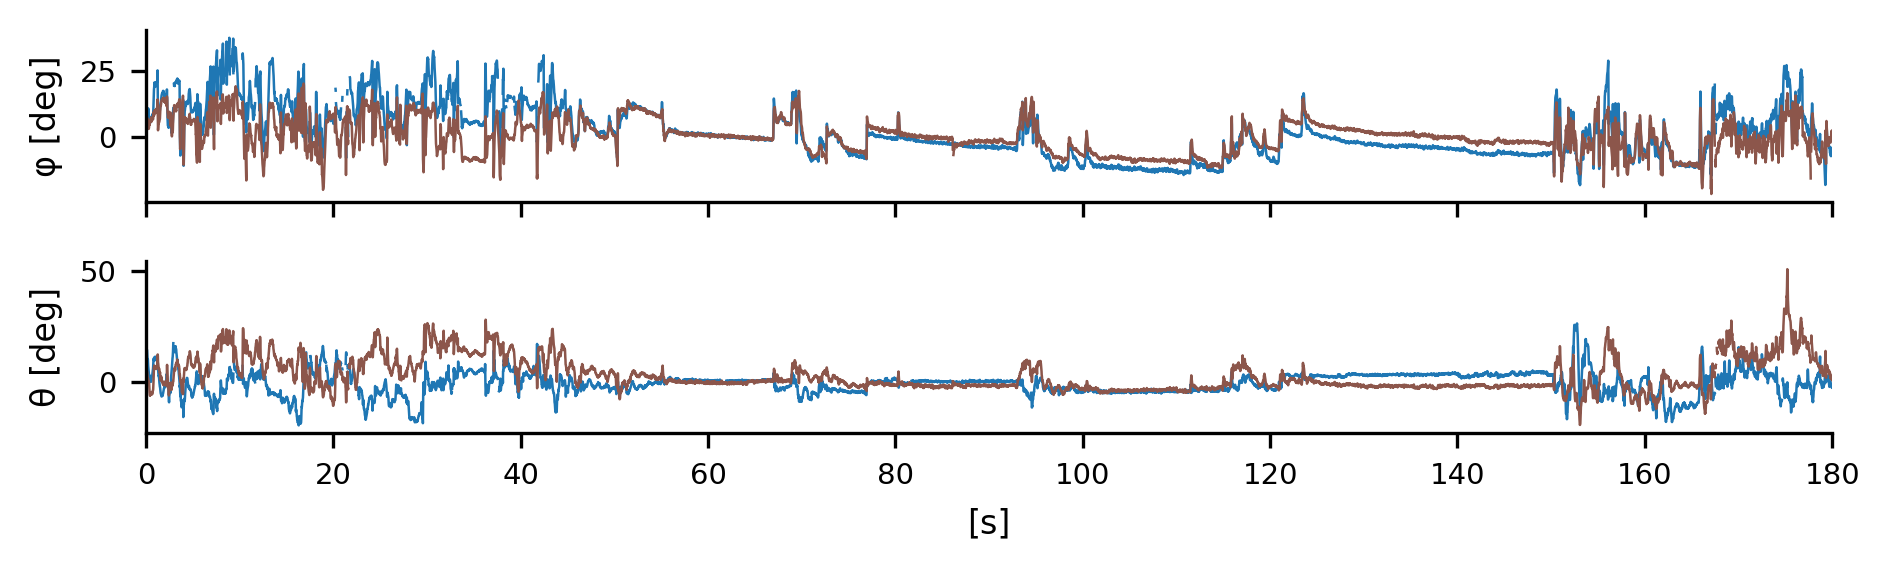

trace_mouse.pdf → /Users/nimi/Projects/PETS/outputs/review_answers_finely_tuned_20260823_19_01/trace_mouse/plots/trace_mouse.pdf


In [17]:
overrides["lizard"]["start_s"] = float(w_liz_start.value)
overrides["lizard"]["end_s"] = float(w_liz_end.value)
overrides["mouse"]["start_s"] = float(w_mouse_start.value)
overrides["mouse"]["end_s"] = float(w_mouse_end.value)
overrides["turtle"]["start_s"] = float(w_turtle_start.value)
overrides["turtle"]["end_s"] = float(w_turtle_end.value)

written = export_species_traces(run, overrides=overrides, show=True, show_animal=["mouse"],export=True)
for name, path in written.items():
    print(name, "→", path)


In [ ]:
overrides["lizard"]["start_s"] = float(w_liz_start.value)
overrides["lizard"]["end_s"] = float(w_liz_end.value)
overrides["mouse"]["start_s"] = float(w_mouse_start.value)
overrides["mouse"]["end_s"] = float(w_mouse_end.value)
overrides["turtle"]["start_s"] = float(w_turtle_start.value)
overrides["turtle"]["end_s"] = float(w_turtle_end.value)

written = export_species_traces(run, overrides=overrides, show=True)
for name, path in written.items():
    print(name, "→", path)
